In [169]:
import pandas as pd 
import numpy as np        
import matplotlib.pyplot as plt  

In [170]:
from pathlib import Path

ROOT = Path.cwd()
if ROOT.name.lower() == "notebooks":
    ROOT = ROOT.parent

raw_data_path = ROOT / "data" / "raw" / "PJME_hourly.csv"
processed_dir = ROOT / "data" / "processed"
figures_dir = ROOT / "figures"

processed_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(raw_data_path)

print("Loaded data from:", raw_data_path)
display(df.head())

Loaded data from: c:\Time series\data\raw\PJME_hourly.csv


,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


In [171]:
df.head(5)

,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


In [172]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145366 entries, 0 to 145365
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  145366 non-null  object 
 1   PJME_MW   145366 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.2+ MB


In [173]:
df.describe()

,PJME_MW
count,145366.000000
mean,32080.222831
std,6464.012166
min,14544.000000
25%,27573.000000
50%,31421.000000
75%,35650.000000
max,62009.000000


## Check Missing Value and Duplicate

In [174]:
print("The number of null values in each column:")
print(df.isnull().sum(), "\n")
print("The number of duplicated rows:")
print(df.duplicated().sum())

The number of null values in each column:
Datetime    0
PJME_MW     0
dtype: int64 

The number of duplicated rows:
0


## Convert Data Type

In [175]:
# Convert Datetime column to datetime format
df["Datetime"] = pd.to_datetime(df["Datetime"])

## Check for duplicate timestamps

In [176]:
df['Datetime'].duplicated().sum()

np.int64(4)

In [177]:
duplicate_mask = df["Datetime"].duplicated(keep=False)

duplicate_rows = df.loc[duplicate_mask].sort_values("Datetime")
duplicate_rows

,Datetime,PJME_MW
106584,2014-11-02 02:00:00,22935.0
106585,2014-11-02 02:00:00,23755.0
115368,2015-11-01 02:00:00,21567.0
115369,2015-11-01 02:00:00,21171.0
124008,2016-11-06 02:00:00,20795.0
124009,2016-11-06 02:00:00,21692.0
132816,2017-11-05 02:00:00,21236.0
132817,2017-11-05 02:00:00,20666.0


*The dataset contains duplicated timestamps, mainly occurring at 02:00 AM in early November. These duplicated timestamps may be related to daylight saving time changes. Since the duplicated timestamps have different electricity load values, removing one observation may lead to information loss. Therefore, duplicated timestamps are handled by averaging the PJME_MW values for the same timestamp.*

In [178]:
# Show shape before handling duplicated timestamps
print("Shape before handling duplicates:", df.shape)

# Handle duplicated timestamps by taking the average PJME_MW value
df_clean = (
    df
    .groupby("Datetime", as_index=False)
    .agg({"PJME_MW": "mean"})
)

# Show shape after handling duplicated timestamps
print("Shape after handling duplicates:", df_clean.shape)

# Check duplicated timestamps again
duplicate_after = df_clean["Datetime"].duplicated().sum()
print("Number of duplicated timestamps after cleaning:", duplicate_after)

# Display cleaned data around duplicated dates
df_clean[df_clean["Datetime"].isin(duplicate_rows["Datetime"].unique())]

Shape before handling duplicates: (145366, 2)
Shape after handling duplicates: (145362, 2)
Number of duplicated timestamps after cleaning: 0


,Datetime,PJME_MW
112487,2014-11-02 02:00:00,23345.0
121222,2015-11-01 02:00:00,21369.0
130125,2016-11-06 02:00:00,21243.5
138860,2017-11-05 02:00:00,20951.0


In [179]:
# Sort by datetime
df_clean = df_clean.sort_values("Datetime")

# Check time range
print("Start date:", df_clean["Datetime"].min())
print("End date:", df_clean["Datetime"].max())

# Check first and last rows
display(df_clean.head())
display(df_clean.tail())

Start date: 2002-01-01 01:00:00
End date: 2018-08-03 00:00:00


,Datetime,PJME_MW
0,2002-01-01 01:00:00,30393.0
1,2002-01-01 02:00:00,29265.0
2,2002-01-01 03:00:00,28357.0
3,2002-01-01 04:00:00,27899.0
4,2002-01-01 05:00:00,28057.0


,Datetime,PJME_MW
145357,2018-08-02 20:00:00,44057.0
145358,2018-08-02 21:00:00,43256.0
145359,2018-08-02 22:00:00,41552.0
145360,2018-08-02 23:00:00,38500.0
145361,2018-08-03 00:00:00,35486.0


In [180]:
# Set datetime as index
df_clean = df_clean.set_index("Datetime")

# Check index
print("Is index monotonic increasing", df_clean.index.is_monotonic_increasing)
print("Duplicated index after setting datetime index:", df_clean.index.duplicated().sum())

display(df_clean.head())

Is index monotonic increasing True
Duplicated index after setting datetime index: 0


,PJME_MW
Datetime,
2002-01-01 01:00:00,30393.0
2002-01-01 02:00:00,29265.0
2002-01-01 03:00:00,28357.0
2002-01-01 04:00:00,27899.0
2002-01-01 05:00:00,28057.0


### Missing Hourly

In [181]:
# Create complete hourly datetime range
full_hourly_range = pd.date_range(
    start=df_clean.index.min(),
    end=df_clean.index.max(),
    freq="h"
)

# Find missing hourly timestamps
missing_timestamps = full_hourly_range.difference(df_clean.index)

print("Number of missing hourly timestamps:", len(missing_timestamps))

# Show missing timestamps
missing_timestamps_df = pd.DataFrame({
    "missing_datetime": missing_timestamps
})

display(missing_timestamps_df)

Number of missing hourly timestamps: 30


,missing_datetime
0,2002-04-07 03:00:00
1,2002-10-27 02:00:00
2,2003-04-06 03:00:00
3,2003-10-26 02:00:00
4,2004-04-04 03:00:00
5,2004-10-31 02:00:00
6,2005-04-03 03:00:00
7,2005-10-30 02:00:00
8,2006-04-02 03:00:00
9,2006-10-29 02:00:00


*The missing hourly timestamps are displayed before treatment. Most missing values occur around daylight saving time changes. However, one missing timestamp, 2010-12-10 00:00:00, does not appear to be related to daylight saving time and is checked separately.*

In [182]:
# Check the unusual missing timestamp not related to daylight saving time
target_ts = pd.Timestamp("2010-12-10 00:00:00")

display(df_clean.loc[
    target_ts - pd.Timedelta(hours=6):
    target_ts + pd.Timedelta(hours=6)
])

,PJME_MW
Datetime,
2010-12-09 18:00:00,42502.0
2010-12-09 19:00:00,42744.0
2010-12-09 20:00:00,42411.0
2010-12-09 21:00:00,41851.0
2010-12-09 22:00:00,40288.0
2010-12-09 23:00:00,37729.0
2010-12-10 01:00:00,33163.0
2010-12-10 02:00:00,32323.0
2010-12-10 03:00:00,32016.0


In [183]:
# Create complete hourly range
full_hourly_range = pd.date_range(
    start=df_clean.index.min(),
    end=df_clean.index.max(),
    freq="h"
)

# Reindex to complete hourly frequency
df_hourly = df_clean.reindex(full_hourly_range)

# Rename index
df_hourly.index.name = "Datetime"

# Show missing values after reindexing
print("Missing values after reindexing:")
print(df_hourly.isnull().sum())

# Display rows with missing PJME_MW
missing_after_reindex = df_hourly[df_hourly["PJME_MW"].isnull()]

print("Number of rows with missing PJME_MW after reindexing:", missing_after_reindex.shape[0])
display(missing_after_reindex)

Missing values after reindexing:
PJME_MW    30
dtype: int64
Number of rows with missing PJME_MW after reindexing: 30


,PJME_MW
Datetime,
2002-04-07 03:00:00,NaN
2002-10-27 02:00:00,NaN
2003-04-06 03:00:00,NaN
2003-10-26 02:00:00,NaN
2004-04-04 03:00:00,NaN
2004-10-31 02:00:00,NaN
2005-04-03 03:00:00,NaN
2005-10-30 02:00:00,NaN
2006-04-02 03:00:00,NaN


*Missing hourly timestamps were identified after checking the regularity of the time index. Since the number of missing observations was very small compared with the full dataset, the missing values were filled using time-based interpolation. This method estimates missing electricity load values based on neighboring observations and helps preserve the continuity of the hourly time series.*

In [184]:
# Fill missing hourly values using time-based interpolation
df_hourly["PJME_MW"] = df_hourly["PJME_MW"].interpolate(method="time")

# Check again after interpolation
print("Missing values after interpolation:")
print(df_hourly.isnull().sum())

# Display interpolated values at previously missing timestamps
display(df_hourly.loc[missing_timestamps])

Missing values after interpolation:
PJME_MW    0
dtype: int64


,PJME_MW
2002-04-07 03:00:00,24612.5
2002-10-27 02:00:00,21714.0
2003-04-06 03:00:00,23123.5
2003-10-26 02:00:00,21822.0
2004-04-04 03:00:00,23354.5
2004-10-31 02:00:00,21806.0
2005-04-03 03:00:00,23577.0
2005-10-30 02:00:00,24462.5
2006-04-02 03:00:00,21144.5
2006-10-29 02:00:00,24342.0


*The dataset was reindexed to a complete hourly time range in order to identify missing hourly observations. After reindexing, timestamps that were absent from the original dataset appeared as missing values. These missing observations were displayed before applying interpolation.**

## Check After Handling

In [185]:
# Final check for hourly cleaned data
print("Start date:", df_hourly.index.min())
print("End date:", df_hourly.index.max())
print("Shape:", df_hourly.shape)

print("Missing values:")
print(df_hourly.isnull().sum())

print("Duplicated timestamps:", df_hourly.index.duplicated().sum())
print("Is index sorted:", df_hourly.index.is_monotonic_increasing)

display(df_hourly.head())
display(df_hourly.tail())

Start date: 2002-01-01 01:00:00
End date: 2018-08-03 00:00:00
Shape: (145392, 1)
Missing values:
PJME_MW    0
dtype: int64
Duplicated timestamps: 0
Is index sorted: True


,PJME_MW
Datetime,
2002-01-01 01:00:00,30393.0
2002-01-01 02:00:00,29265.0
2002-01-01 03:00:00,28357.0
2002-01-01 04:00:00,27899.0
2002-01-01 05:00:00,28057.0


,PJME_MW
Datetime,
2018-08-02 20:00:00,44057.0
2018-08-02 21:00:00,43256.0
2018-08-02 22:00:00,41552.0
2018-08-02 23:00:00,38500.0
2018-08-03 00:00:00,35486.0


## Resample from Hourly to Weekly

In [186]:
# Calculate the total electricity consumption for each week based on hourly data.
# Resample hourly electricity load to weekly electricity consumption

weekly_data = df_hourly.resample("W-SUN").sum()

# Rename column
weekly_data = weekly_data.rename(columns={
    "PJME_MW": "Weekly_Electricity_Consumption_MWh"
})

print("Weekly data shape:", weekly_data.shape)
display(weekly_data.head())
display(weekly_data.tail())

Weekly data shape: (866, 1)


,Weekly_Electricity_Consumption_MWh
Datetime,
2002-01-06,4632079.0
2002-01-13,5289881.0
2002-01-20,5284084.0
2002-01-27,5063777.0
2002-02-03,4905010.0


,Weekly_Electricity_Consumption_MWh
Datetime,
2018-07-08,6461277.0
2018-07-15,6118566.0
2018-07-22,5982832.0
2018-07-29,6145746.0
2018-08-05,3547174.0


### Check If We Have Enough Observed Hours or not

In [187]:
# Count the number of hourly observations in each week
weekly_hour_count = df_hourly["PJME_MW"].resample("W-SUN").count()

# Create weekly completeness table
week_check = weekly_hour_count.to_frame(name="Observed_Hours")
week_check["Expected_Hours"] = 168
week_check["Is_Complete"] = week_check["Observed_Hours"] == week_check["Expected_Hours"]

# Show incomplete weeks
incomplete_weeks = week_check[week_check["Is_Complete"] == False]

print("Number of incomplete weeks:", incomplete_weeks.shape[0])
display(incomplete_weeks)

Number of incomplete weeks: 2


,Observed_Hours,Expected_Hours,Is_Complete
Datetime,,,
2002-01-06,143,168,False
2018-08-05,97,168,False


In [188]:
# Keep only complete weeks
complete_weeks = week_check[week_check["Is_Complete"] == True].index

weekly_clean = weekly_data.loc[weekly_data.index.isin(complete_weeks)]

print("Weekly data before removing incomplete weeks:", weekly_data.shape)
print("Weekly data after removing incomplete weeks:", weekly_clean.shape)

display(weekly_clean.head())
display(weekly_clean.tail())

Weekly data before removing incomplete weeks: (866, 1)
Weekly data after removing incomplete weeks: (864, 1)


,Weekly_Electricity_Consumption_MWh
Datetime,
2002-01-13,5289881.0
2002-01-20,5284084.0
2002-01-27,5063777.0
2002-02-03,4905010.0
2002-02-10,5233287.0


,Weekly_Electricity_Consumption_MWh
Datetime,
2018-07-01,6033189.0
2018-07-08,6461277.0
2018-07-15,6118566.0
2018-07-22,5982832.0
2018-07-29,6145746.0


In [189]:
# Create final dataset for ARIMA modeling
final_df = weekly_clean.copy()

print(final_df.info())
display(final_df.head())
display(final_df.tail())

print("Missing values:")
print(final_df.isnull().sum())

print("Duplicated weekly dates:", final_df.index.duplicated().sum())
print("Is index sorted:", final_df.index.is_monotonic_increasing)

print("Start date:", final_df.index.min())
print("End date:", final_df.index.max())
print("Number of observations:", final_df.shape[0])

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 864 entries, 2002-01-13 to 2018-07-29
Freq: W-SUN
Data columns (total 1 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Weekly_Electricity_Consumption_MWh  864 non-null    float64
dtypes: float64(1)
memory usage: 13.5 KB
None


,Weekly_Electricity_Consumption_MWh
Datetime,
2002-01-13,5289881.0
2002-01-20,5284084.0
2002-01-27,5063777.0
2002-02-03,4905010.0
2002-02-10,5233287.0


,Weekly_Electricity_Consumption_MWh
Datetime,
2018-07-01,6033189.0
2018-07-08,6461277.0
2018-07-15,6118566.0
2018-07-22,5982832.0
2018-07-29,6145746.0


Missing values:
Weekly_Electricity_Consumption_MWh    0
dtype: int64
Duplicated weekly dates: 0
Is index sorted: True
Start date: 2002-01-13 00:00:00
End date: 2018-07-29 00:00:00
Number of observations: 864


## After Handling Data

In [190]:
# Define target variable
y = final_df["Weekly_Electricity_Consumption_MWh"]

print("Start date:", y.index.min())
print("End date:", y.index.max())
print("Number of observations:", y.shape[0])

display(y.head())
display(y.tail())

Start date: 2002-01-13 00:00:00
End date: 2018-07-29 00:00:00
Number of observations: 864


Datetime
2002-01-13    5289881.0
2002-01-20    5284084.0
2002-01-27    5063777.0
2002-02-03    4905010.0
2002-02-10    5233287.0
Freq: W-SUN, Name: Weekly_Electricity_Consumption_MWh, dtype: float64

Datetime
2018-07-01    6033189.0
2018-07-08    6461277.0
2018-07-15    6118566.0
2018-07-22    5982832.0
2018-07-29    6145746.0
Freq: W-SUN, Name: Weekly_Electricity_Consumption_MWh, dtype: float64

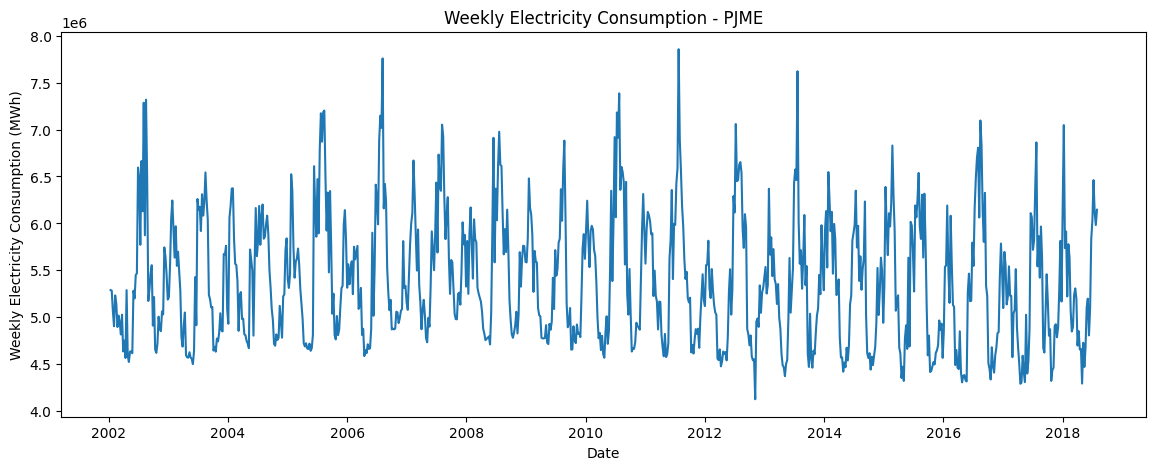

In [191]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(y)
plt.title("Weekly Electricity Consumption - PJME")
plt.xlabel("Date")
plt.ylabel("Weekly Electricity Consumption (MWh)")
plt.show()

The figure shows the weekly electricity consumption of the PJM East region over the sample period. The series fluctuates strongly over time, with repeated peaks and troughs. Compared with the previous daily series, weekly aggregation reduces day-of-week fluctuations and provides a smoother view of electricity consumption patterns.

The series still shows clear cyclical movements, suggesting the presence of seasonal behavior even after weekly aggregation. Several high-consumption weeks can be observed, which may correspond to periods of peak electricity demand. However, there is no clear long-term upward or downward trend across the whole sample period.

This full-sample plot is used only for descriptive exploratory analysis. Formal model identification, including stationarity testing and ACF/PACF analysis, will be conducted using only the training set to avoid data leakage.

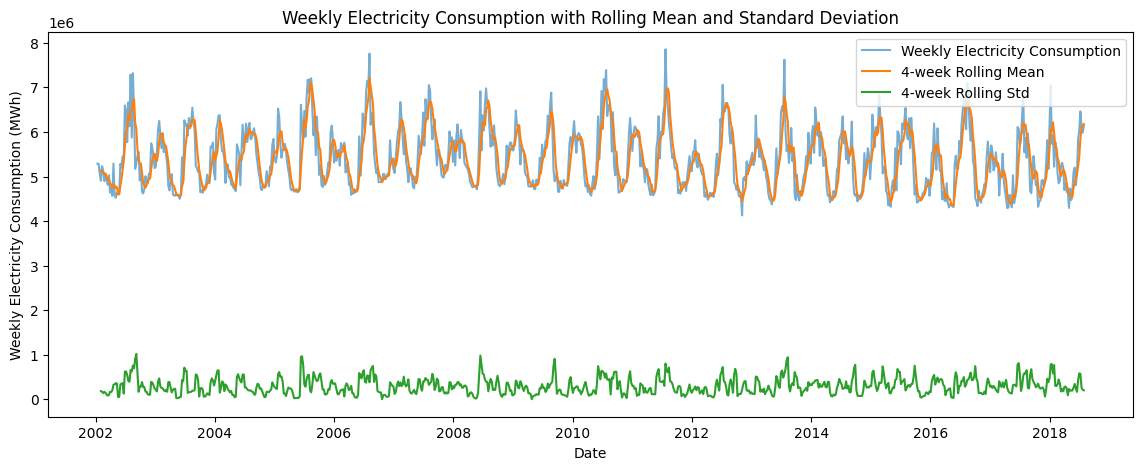

In [192]:
plt.figure(figsize=(14, 5))
plt.plot(y, label="Weekly Electricity Consumption", alpha=0.6)
plt.plot(y.rolling(window=4).mean(), label="4-week Rolling Mean")
plt.plot(y.rolling(window=4).std(), label="4-week Rolling Std")
plt.title("Weekly Electricity Consumption with Rolling Mean and Standard Deviation")
plt.xlabel("Date")
plt.ylabel("Weekly Electricity Consumption (MWh)")
plt.legend()
plt.show()

### Rolling Mean and Rolling Standard Deviation

The figure presents weekly electricity consumption together with its 4-week rolling mean and 4-week rolling standard deviation. The 4-week rolling mean smooths short-term fluctuations and helps reveal the underlying movement of weekly electricity consumption. The 4-week rolling standard deviation provides a visual indication of changes in variability over time.

The rolling mean follows a repeated cyclical pattern, indicating that electricity consumption still contains seasonal movements after weekly aggregation. The rolling standard deviation also changes over time, suggesting that the variability of weekly electricity consumption is not completely constant throughout the sample period.

This plot is used only for descriptive exploratory analysis. Stationarity testing and ARIMA model identification will be performed on the training set only to avoid data leakage.

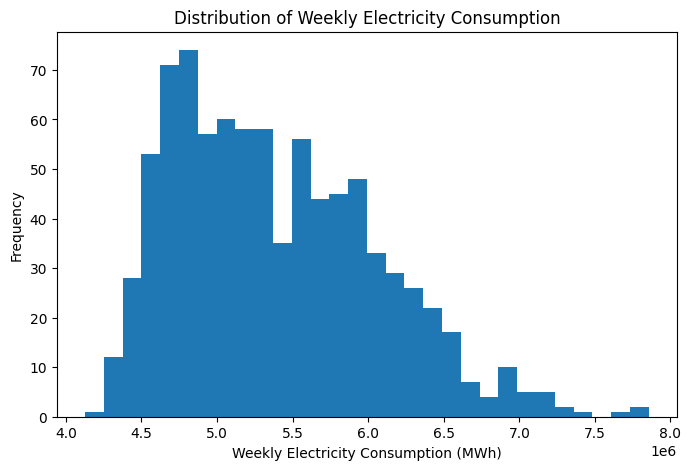

In [193]:
plt.figure(figsize=(8, 5))
plt.hist(y.dropna(), bins=30)

plt.title("Distribution of Weekly Electricity Consumption")
plt.xlabel("Weekly Electricity Consumption (MWh)")
plt.ylabel("Frequency")

plt.savefig(figures_dir / "weekly_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

### Distribution of Weekly Electricity Consumption

The histogram shows the distribution of weekly electricity consumption after aggregating the original hourly PJME load data into weekly MWh. Most weekly observations are concentrated between approximately 4.5 million and 6.0 million MWh, indicating that this is the common range of weekly electricity consumption in the dataset.

The distribution is slightly right-skewed, with a small number of weeks having consumption above 7 million MWh. These high values may represent genuine peak-demand periods rather than data errors. Therefore, they are retained in the dataset instead of being removed as outliers.

This distribution is also useful for interpreting forecasting errors. Since some weeks have very high consumption, error metrics such as RMSE may become large in absolute value. For this reason, the model performance should be evaluated using MAE, RMSE, and MAPE together.


## Split Data

In [194]:
# Chronological train-validation-test split
val_size = 52
test_size = 13

train = y.iloc[:-(val_size + test_size)]
val = y.iloc[-(val_size + test_size):-test_size]
test = y.iloc[-test_size:]

print("Train period:", train.index.min(), "to", train.index.max())
print("Validation period:", val.index.min(), "to", val.index.max())
print("Test period:", test.index.min(), "to", test.index.max())

print("Train size:", train.shape[0])
print("Validation size:", val.shape[0])
print("Test size:", test.shape[0])

Train period: 2002-01-13 00:00:00 to 2017-04-30 00:00:00
Validation period: 2017-05-07 00:00:00 to 2018-04-29 00:00:00
Test period: 2018-05-06 00:00:00 to 2018-07-29 00:00:00
Train size: 799
Validation size: 52
Test size: 13


### Train-Validation-Test Split

The weekly dataset is split chronologically into training, validation, and testing sets. The validation set contains 52 weeks, representing approximately one year, while the test set contains the final 13 weeks. The training set is used for stationarity testing and model estimation, the validation set is used for model selection, and the test set is kept unseen until the final evaluation to avoid data leakage.

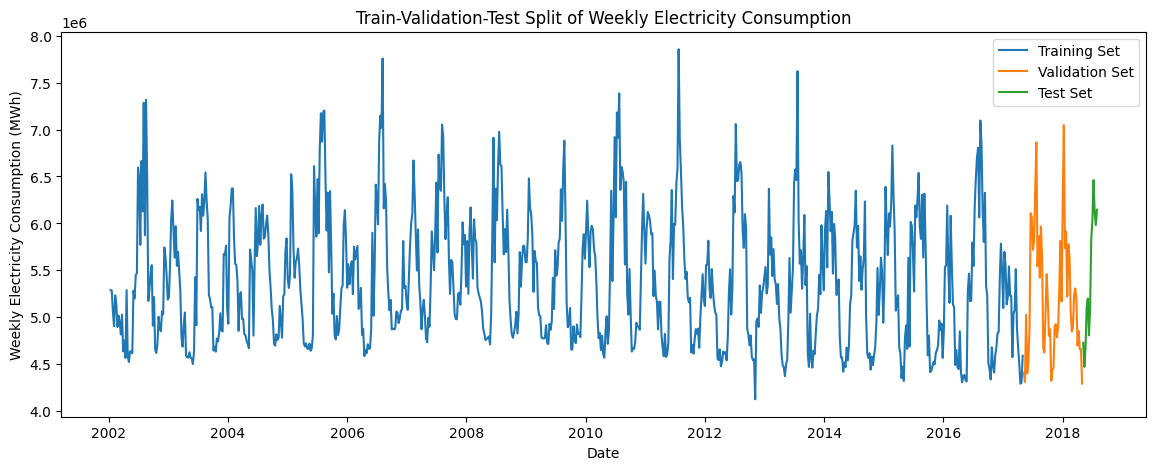

In [195]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

plt.plot(train, label="Training Set")
plt.plot(val, label="Validation Set")
plt.plot(test, label="Test Set")

plt.title("Train-Validation-Test Split of Weekly Electricity Consumption")
plt.xlabel("Date")
plt.ylabel("Weekly Electricity Consumption (MWh)")
plt.legend()

plt.savefig(figures_dir / "train_val_test_split.png", dpi=300, bbox_inches="tight")
plt.show()

In [196]:
import json

processed_dir.mkdir(parents=True, exist_ok=True)

# Save final weekly dataset
final_df_export = final_df.copy()
final_df_export.index.name = "Datetime"

final_df_export.to_csv(
    processed_dir / "weekly_pjme_consumption_processed.csv",
    index=True
)

# Save train / validation / test separately
train.to_frame(name="Weekly_Electricity_Consumption_MWh").to_csv(
    processed_dir / "train_weekly_pjme.csv",
    index=True,
    index_label="Datetime"
)

val.to_frame(name="Weekly_Electricity_Consumption_MWh").to_csv(
    processed_dir / "validation_weekly_pjme.csv",
    index=True,
    index_label="Datetime"
)

test.to_frame(name="Weekly_Electricity_Consumption_MWh").to_csv(
    processed_dir / "test_weekly_pjme.csv",
    index=True,
    index_label="Datetime"
)

# Save metadata for reproducibility
metadata = {
    "target_column": "Weekly_Electricity_Consumption_MWh",
    "frequency": "W-SUN",
    "total_observations": int(final_df.shape[0]),
    "start_date": str(final_df.index.min().date()),
    "end_date": str(final_df.index.max().date()),
    "train_start": str(train.index.min().date()),
    "train_end": str(train.index.max().date()),
    "validation_start": str(val.index.min().date()),
    "validation_end": str(val.index.max().date()),
    "test_start": str(test.index.min().date()),
    "test_end": str(test.index.max().date()),
    "validation_size": int(len(val)),
    "test_size": int(len(test))
}

with open(processed_dir / "metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

print("Export completed.")
print("Saved files to:", processed_dir)

Export completed.
Saved files to: c:\Time series\data\processed
